In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn

# Generate Data

In [2]:
# Definition of the function to be estimated
def function_to_be_estimated(x, random_seed=0, noise=True):
    torch.manual_seed(random_seed)
    y = torch.exp(0.1*x)*0.5 + 0.5*torch.sin(2*torch.pi*x/10)
    if noise:
        y += 0.5*torch.randn(x.shape[0], x.shape[1])         
    return y

Text(0, 0.5, 'y')

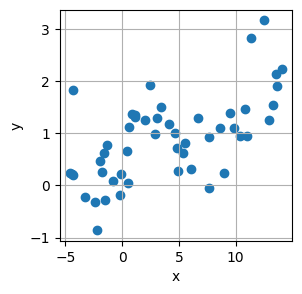

In [3]:
# Random sample generation
torch.manual_seed(0)
n_samples = 50
x_train = 20*torch.rand(n_samples,1)-5
y_train = function_to_be_estimated(x_train)

# Plot the samples
plt.figure(figsize=(3,3))
plt.scatter(x_train, y_train)
plt.grid("on")
plt.xlabel("x")
plt.ylabel("y")

# Define the Model

In [4]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(1, 1, bias=True)
    def forward(self, X):
        return self.linear_layer(X)

In [5]:
# Create model and print initial values (random init)
model = LinearModel()
print(model.linear_layer.weight)
print(model.linear_layer.bias)

Parameter containing:
tensor([[0.0382]], requires_grad=True)
Parameter containing:
tensor([0.2317], requires_grad=True)


# Learn the model with observations
## Gradient descent
We have some data and the model. To learn the model parameter we need two additional ingredients: the loss function and the optimizer. In this simple case, we will the square error and the objective function will be the mean square error. For the optimizer, we will use a simple gradient descent.

In [6]:
loss_fn = nn.MSELoss()
n_epochs = 100
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

We can iterate gradient update until convergence and make use of autograd to let pytorch computes the derivative by itself.

In [7]:
model.train()
loss_val = []
for epoch in range(n_epochs):
    # Forward pass
    y_hat = model(x_train)

    # Compute objective
    loss = loss_fn(y_train, y_hat)
    loss_val.append(loss.item())
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if epoch % 10 == 0:
        print(f" Epoch: {epoch}: {loss.item():.5f}")

 Epoch: 0: 0.75388
 Epoch: 10: 0.45800
 Epoch: 20: 0.44646
 Epoch: 30: 0.43758
 Epoch: 40: 0.43076
 Epoch: 50: 0.42552
 Epoch: 60: 0.42149
 Epoch: 70: 0.41839
 Epoch: 80: 0.41601
 Epoch: 90: 0.41418


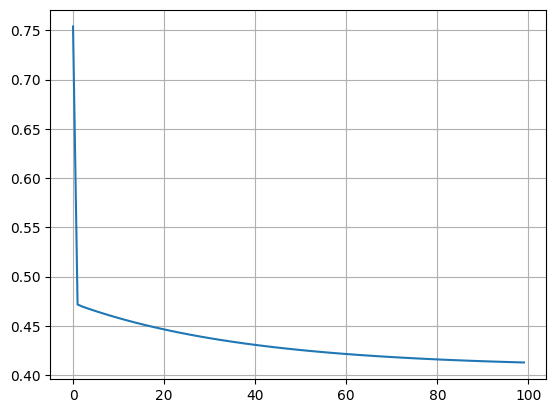

In [8]:
plt.plot(loss_val)
plt.grid("on")

In [9]:
print(model.linear_layer.weight)
print(model.linear_layer.bias)

Parameter containing:
tensor([[0.0947]], requires_grad=True)
Parameter containing:
tensor([0.4680], requires_grad=True)


### Plot the final estimation

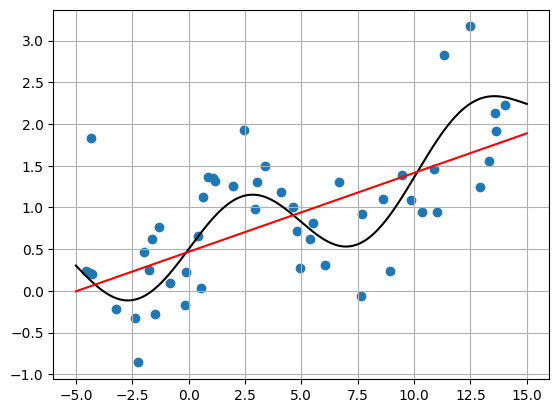

In [10]:
model.eval()
x = torch.linspace(-5, 15, 1000)
y_true = function_to_be_estimated(x, noise=False)
model.eval()
with torch.no_grad():
    y_hat = model(torch.unsqueeze(x, 1))
plt.plot(x, y_true, 'k')
plt.plot(x, y_hat.detach().numpy(), 'r')
plt.scatter(x_train, y_train)
plt.grid("on")

## Some points to investigate before going further
- Change the learning rate of the optimizer to see how it changes the convergence.
- Change the to batch gradient update, using pytorch dataloader (https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)
- Try to improve your fit:
    - Increase the number of training samples: what does it change in the final result ? 
    - Add another linear layer in your model: what does it change in the final result ?
    - Implement polynomial regression using $\phi(x)=[1, x, x^2, ..., x^p]$. Does it helps ?